<h1>California Houses Prediction</h1>

This project aims to make a prediction of the housing prices using machine learning techniques applied to the California Housing dataset, a populare dataset leveraging informations abour a strict area, like number of population, geographic coordinates etc.

The goal is to build and evaluate regression models necessary to understand median home values ​​based on the features of the dataset.

Exploratory data analysis (EDA) is used in a structured environment to analyze the dataset's aggregate characteristics, including feature distributions and potential skewness.

Multiple regression models are considered, ranging from simple approaches to more complex ones:
- Linear Regression
- Random Forest
- XGBoost

Particular attention is paid to evaluating model performance through cross-validation, ensuring robust and reliable evaluation.

Additional feature engineering techniques are introduced to capture relationships between variables to enhance model performance. The impact of these changes is measured by providing before and after results.

Finally, the best-performing model is further optimized through hyperparameter tuning. The project concludes with an in-depth analysis of the model's behavior to reveal key insights.

# Setup & Load Dataset

The required libraries are imported and the dataset is loaded.

A random selected seed is also set to ensure reproducibility of the results.

In [1]:
import os
import json
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

random_seed = 42
np.random.seed(random_seed)

In [2]:
from pandas import DataFrame, Series
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)
df = data.frame

# Exploratory Data Analysis (EDA)

In this phase, an initial exploration of the dataset is performed to understand its structure and main characteristics.

In [3]:
df.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


The dataset is composed by the following features:
- **MedInc**: Median income of households in a block group (measured in tens of thousands of US dollars).
- **HouseAge**: Median age of houses in the block group.
- **AveRooms**: Average number of rooms per household.
- **AveBedrms**: Average number of bedrooms per household.
- **Popoulation**: Total number of people living in the block group.
- **AveOccup**: Average number of people per household.
- **Latitude**: Geographic latitude of the block group.
- **Longitude**: Geographic longitude of the block group.
- **MedHouseVal** (*target variable*): Median house value in the block group (measured in hundreds of thousands of US dollars).


In [4]:
def info_data_report(df: pd.DataFrame) -> pd.DataFrame:
    report = pd.DataFrame({
        "n_rows": len(df.index),
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_%": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(dropna=True),
    })
    return report.sort_values("missing", ascending=False)

display(info_data_report(df))

,n_rows,dtype,missing,missing_%,n_unique
MedInc,20640,float64,0,0.0,12928
HouseAge,20640,float64,0,0.0,52
AveRooms,20640,float64,0,0.0,19392
AveBedrms,20640,float64,0,0.0,14233
Population,20640,float64,0,0.0,3888
AveOccup,20640,float64,0,0.0,18841
Latitude,20640,float64,0,0.0,862
Longitude,20640,float64,0,0.0,844
MedHouseVal,20640,float64,0,0.0,3842


The dataset consists of 20,640 numerical instances, indicating that no additional transformations such as type casting or one-hot encoding are required. Furthermore, the absence of missing values reduces the number of preprocessing operations.

Moreover, the unique values of the features do not appear to indicate anomalous or irregular distributions within the dataset. For instance, unusually high values for variables such as age (e.g., values exceeding 100) or an excessive number of distinct geographical coordinates would have been considered suspicious.

In [5]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Several features exhibit a significant difference between minimum and maximum values, along with a high standard deviation compared to the mean. This is evident on features such as *Population* and *AveOccup*, suggesting the presence of potential outliers or highly skewed distributions.

On the other hand, features such as *MedInc* and *HouseAge* appear to have more stable and consistent distributions.

It is also worth noting that some variables, such as *AveRooms* and *AveBedrms*, present high maximum values compared to their quartiles, further suggesting the presence of skewed distributions.

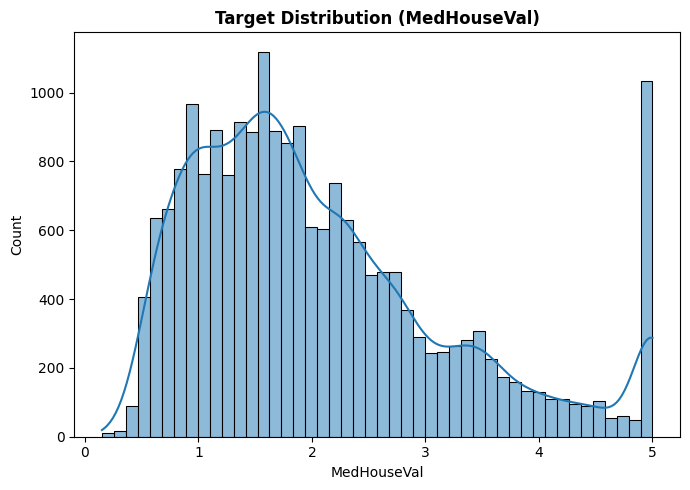

In [6]:
plt.figure(figsize=(7, 5))
sns.histplot(df['MedHouseVal'], kde=True)
plt.title(f"Target Distribution (MedHouseVal)", fontweight="bold")
plt.tight_layout()
plt.show()

The distribution of the target variable ranges from 0 to 5, and shows a noteworthy distribution. A noticeable spike is present at the maximum value, suggesting that the dataset has an upper limit. This means that all values above a certain threshold are grouped at this maximum value, which may reduce the model’s ability to accurately learn and predict higher values.



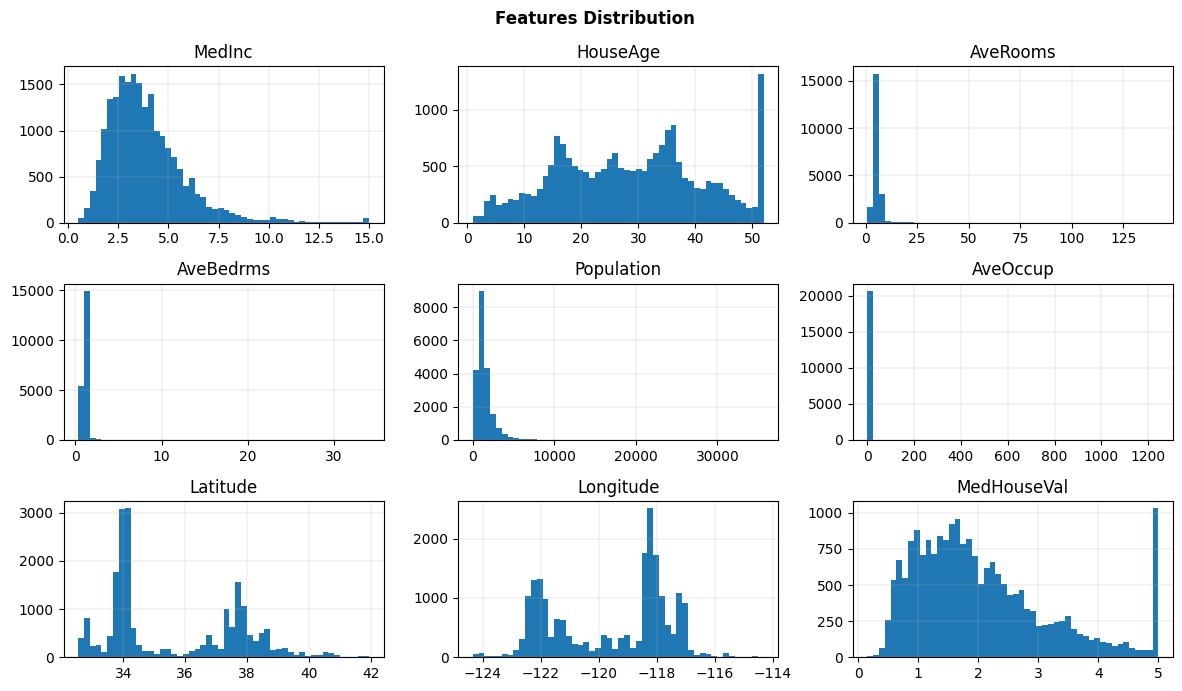

AveOccup       97.639561
AveBedrms      31.316956
AveRooms       20.697869
Population      4.935858
MedInc          1.646657
MedHouseVal     0.977763
Latitude        0.465953
HouseAge        0.060331
Longitude      -0.297801
dtype: float64


In [7]:
axes = df.hist(figsize=(12, 7), bins=50)

for ax in axes.flatten():
    ax.grid(True, linewidth=0.2)

plt.suptitle("Features Distribution", fontweight="bold")
plt.tight_layout()
plt.show()

print(df.skew(numeric_only=True).sort_values(ascending=False))

As previously anticipated, the distribution of the features reveals significant skewness in several variables.

In particular, *AveOccup*, *AveBedrms*, and *AveRooms* exhibit extremely high skewness, indicating the presence of long right tails and extreme values. This suggests that these features contain outliers or very large observations. *Population* also shows noticeable skewness, although to a slight lesser extent.

The presence of skewness can be problematic for linear models such as Linear Regression. Therefore, appropriate mitigation techniques may be required to improve model effectiveness. On the other hand, models such as Random Forest and XGBoost are generally more robust to such distributions and are expected to handle these features more effectively.

It can also be observed that the *HouseAge* variable exhibits a similar issue to the target variable, as it appears to be capped at 52. This suggests that values beyond this threshold are truncated, potentially leading to similar limitations as the target variable.

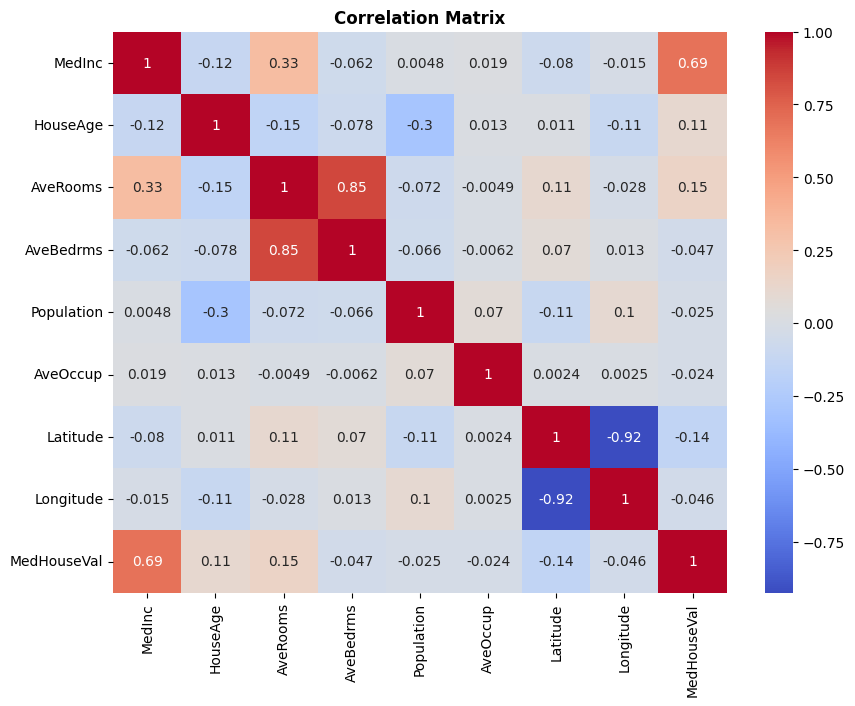

In [10]:
plt.figure(figsize=(9,7))
sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    annot=True
)
plt.tight_layout()
plt.title("Correlation Matrix", fontweight="bold")
plt.show()

The correlation matrix highlights the relationships between every feature of the dataset.

The most relevant correlation for the predictions models is the strong positive correlation between *MedInc* and the target variable *MedHouseVal*, indicating that higher median incomes levels are generally associated with higher housing prices. This feature is therefore expected to play a key role in the prediction task.

Apart from this, the dataset does not exhibit strong linear correlations among most variables. The main exceptions are the pair *Latitude*-*Longitude*, which shows a strong negative correlation, and *AveRooms*-*AveBedrms*, suggesting a degree of redundancy between these features.

# Preprocessing

In this phase, the dataset is prepared for model training.

From a feature engineering perspective, several new derived features have been introduced with the aim of capturing more meaningful relationships between the original variables. These include:
- **RoomsPerHousehold**: a highly informative feature, as it reflects not only the total number of rooms but also how many are available per household.
- **BedroomsRatio**: the proportion of bedrooms relative to the total number of rooms, providing insight into the internal structure of the houses.
- **PopulationPerHousehold**: a measure of population density per household, which may indicate whether an area is more crowded or sparsely populated.
- **IncomePerHousehold**: captures the relationship between income and the number of individuals per household.

The impact of these new features will be evaluated by comparing model performance before and after their introduction.

Due to the relatively low dimensionality of the dataset, no explicit feature selection methods were employed.

In [11]:
df_fe = df.copy()

In [12]:
df_fe["RoomsPerHousehold"] = df_fe["AveRooms"] / df_fe["AveOccup"]

In [13]:
df_fe["BedroomsRatio"] = df_fe["AveBedrms"] / df_fe["AveRooms"]

In [14]:
df_fe["PopulationPerHousehold"] = df_fe["Population"] / df_fe["AveOccup"]

In [15]:
df_fe["IncomePerHousehold"] = df_fe["MedInc"] / df_fe["AveOccup"]

In [16]:
# Target variable separation

X = df.drop(columns="MedHouseVal")
y = df['MedHouseVal']

X_fe = df_fe.drop(columns="MedHouseVal")
y_fe = df_fe['MedHouseVal']

In [17]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler() # Used only for linear regression

Feature scaling was applied using StandardScaler exclusively for the Linear Regression model, as it is sensitive to the scale of the input variables. In contrast, tree-based models do not require normalization and were trained on the original data.

In [18]:
from sklearn.model_selection import train_test_split

def get_train_test(X: DataFrame, y: Series):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state = random_seed,
        )
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = get_train_test(X, y)
X_train_fe, X_test_fe, y_train_fe, y_test_fe = get_train_test(X_fe, y_fe)

The dataset was split into training and test sets using a test size of 0.2. This choice ensures a sufficiently large test set to reliably evaluate the models’ predictive performance, while still retaining a substantial portion of data for training.

# Cross-Validation

To obtain a reliable estimate of model performance, K-Fold cross-validation is applied. The dataset is split into 5 folds, and the model is trained and evaluated multiple times, each time using a different fold as validation data.

For each model, three evaluation metrics are computed:

- **RMSE** (Root Mean Squared Error): penalizes larger errors more heavily.

- **MAE** (Mean Absolute Error): provides a more interpretable average error.

- **R²** (Coefficient of Determination): measures the proportion of variance explained by the model.

Cross-validation is applied across all models and both dataset versions (original and feature-engineered), enabling a fair comparison of their performance.

In [19]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error

def regression_metrics(y_true, y_pred) -> dict:
    return {
        "RMSE": float(root_mean_squared_error(y_true, y_pred)),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
    }

In [20]:
from sklearn.model_selection import KFold

cross_validation = KFold(n_splits=5, shuffle=True, random_state=random_seed)

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import copy

pipeline_linearregression = Pipeline([
    ("scaler", standard_scaler),
    ("model", LinearRegression())
])
pipeline_linearregression_fe = copy.deepcopy(pipeline_linearregression)

In [22]:
from sklearn.ensemble import RandomForestRegressor

random_forest = RandomForestRegressor(random_state=random_seed)
random_forest_fe = copy.deepcopy(random_forest)

In [23]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=random_seed)
xgb_fe = copy.deepcopy(xgb)

In [24]:
from sklearn.model_selection import cross_validate

def cross_validation_function(model, X, y, cv):
  return cross_validate(
      model,
      X,
      y,
      cv=cv,
      scoring={
          "rmse": "neg_root_mean_squared_error",
          "mae": "neg_mean_absolute_error",
          "r2": "r2"
      }
  )

cross_validation_linearregression = cross_validation_function(pipeline_linearregression, X, y, cross_validation)
cross_validation_linearregression_fe = cross_validation_function(pipeline_linearregression_fe, X_fe, y_fe, cross_validation)

cross_validation_random_forest = cross_validation_function(random_forest, X, y, cross_validation)
cross_validation_random_forest_fe = cross_validation_function(random_forest_fe, X_fe, y_fe, cross_validation)

cross_validation_xgb = cross_validation_function(xgb, X, y, cross_validation)
cross_validation_xgb_fe = cross_validation_function(xgb_fe, X_fe, y_fe, cross_validation)

In [25]:
def results_to_df(results, name):
    return pd.DataFrame({
        "model": [name],
        "RMSE_mean": [-results["test_rmse"].mean()],
        "RMSE_std": [results["test_rmse"].std()],
        "MAE_mean": [-results["test_mae"].mean()],
        "MAE_std": [results["test_mae"].std()],
        "R2_mean": [results["test_r2"].mean()],
        "R2_std": [results["test_r2"].std()]
    })

df_results = pd.concat([
    results_to_df(cross_validation_linearregression, "LinearRegression"),
    results_to_df(cross_validation_linearregression_fe, "LinearRegression_FE"),
    results_to_df(cross_validation_random_forest, "RandomForest"),
    results_to_df(cross_validation_random_forest_fe, "RandomForest_FE"),
    results_to_df(cross_validation_xgb, "XGBoost"),
    results_to_df(cross_validation_xgb_fe, "XGBoost_FE"),
], ignore_index=True)

df_results = df_results.round(3)
df_results

,model,RMSE_mean,RMSE_std,MAE_mean,MAE_std,R2_mean,R2_std
0,LinearRegression,0.728,0.015,0.532,0.008,0.601,0.017
1,LinearRegression_FE,0.657,0.012,0.472,0.009,0.676,0.011
2,RandomForest,0.503,0.009,0.328,0.006,0.810,0.007
3,RandomForest_FE,0.483,0.009,0.308,0.006,0.825,0.007
4,XGBoost,0.469,0.010,0.307,0.006,0.835,0.008
5,XGBoost_FE,0.464,0.014,0.304,0.008,0.838,0.010


The results show that XGBoost achieves the best overall performance, followed by Random Forest. Feature engineering has a significant impact on Linear Regression substantially improving performance, while the benefit for tree-based models appears to be more limited.

Moreover, one of the most important findings from the cross-validation process is the low variability of the evaluation metrics across the folds, indicating a good level of model stability.

# Hyperparameter Tuning

Since XGBoost trained on the feature-engineered dataset achieved the best performance, hyperparameter tuning was applied to further improve the model. In particular, RandomizedSearchCV was used, a technique that identifies the optimal combination of model parameters by sampling a fixed number of configurations from a predefined search space.

The following hyperparameters are considered:

- **n_estimators**: number of trees in the model.

- **max_depth**: maximum depth of each tree. Deeper trees can capture more complex patterns but may lead to overfitting.

- **learning_rate**: step size used in boosting. Lower values make learning more gradual.

- **subsample**: fraction of training data used for each tree. Helps reduce overfitting by introducing randomness.

- **colsample_bytree**: fraction of features used for each tree. Also reduces overfitting and increases model robustness.

The best combination of these parameters is selected using cross-validation with RMSE as the evaluation metric.



In [33]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb_fe,
    param_distributions=param_dist,
    n_iter=15,
    cv=cross_validation,
    scoring="neg_root_mean_squared_error",
    random_state=random_seed,
    verbose=1
)

In [34]:
pipeline_linearregression.fit(X_train, y_train)
pipeline_linearregression_fe.fit(X_train_fe, y_train)

random_forest.fit(X_train, y_train)
random_forest_fe.fit(X_train_fe, y_train)

xgb.fit(X_train, y_train)
random_search.fit(X_train_fe, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=Non...
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=15,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 5, 6],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

# Evaluation

In this phase, predictions are performed on the target variable using all the considered models and dataset versions.

For XGBoost trained on the feature-engineered dataset, the hyperparameters identified as optimal during the tuning phase are used.

In [35]:
y_pred_linearregression = pipeline_linearregression.predict(X_test)
y_pred_linearregression_fe = pipeline_linearregression_fe.predict(X_test_fe)

y_pred_random_forest = random_forest.predict(X_test)
y_pred_random_forest_fe = random_forest_fe.predict(X_test_fe)

y_pred_xgb = xgb.predict(X_test)

In [36]:
xgb_fe_best_model = random_search.best_estimator_
print("Best parameters XGBoost:", random_search.best_params_)
y_pred_xgb_fe_tuned = xgb_fe_best_model.predict(X_test_fe)

Best parameters XGBoost: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [37]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

In [38]:
results = []

results.append({"Model": "LinearRegression", **evaluate_model(y_test, y_pred_linearregression)})
results.append({"Model": "LinearRegression_FE", **evaluate_model(y_test, y_pred_linearregression_fe)})

results.append({"Model": "RandomForest", **evaluate_model(y_test, y_pred_random_forest)})
results.append({"Model": "RandomForest_FE", **evaluate_model(y_test, y_pred_random_forest_fe)})

results.append({"Model": "XGBoost", **evaluate_model(y_test, y_pred_xgb)})
results.append({"Model": "XGBoost_FE_Tuned", **evaluate_model(y_test, y_pred_xgb_fe_tuned)})

In [39]:
results_df = pd.DataFrame(results)
results_df = results_df.round(3)

# Results Analysis

In [40]:
results_df

,Model,RMSE,MAE,R2
0,LinearRegression,0.746,0.533,0.576
1,LinearRegression_FE,0.662,0.475,0.666
2,RandomForest,0.505,0.328,0.805
3,RandomForest_FE,0.482,0.307,0.823
4,XGBoost,0.472,0.310,0.830
5,XGBoost_FE_Tuned,0.457,0.299,0.841


The results, as already highlighted by the cross-validation process, confirm that XGBoost trained on the feature-engineered dataset is the best-performing model for this task. Additionally, hyperparameter optimization led to a further, slight, improvement in performance.

The consistency between the cross-validation results and those obtained on the test set further confirms the models’ good generalization capability.

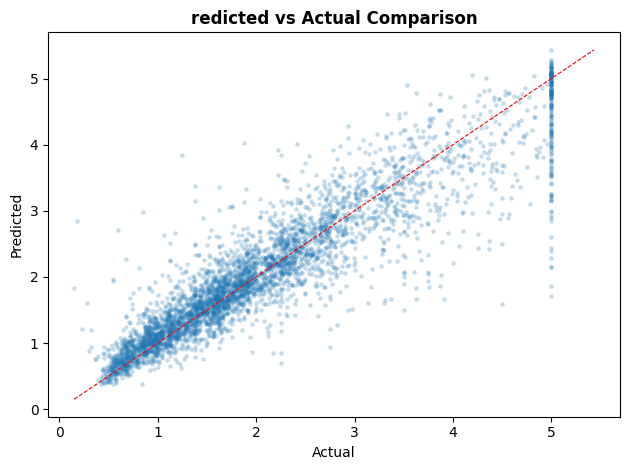

In [42]:
plt.figure()
sns.scatterplot(x=y_test, y=y_pred_xgb_fe_tuned, alpha=0.25, s=8, edgecolor=None)

# linea diagonale
min_val = min(min(y_test), min(y_pred_xgb_fe_tuned))
max_val = max(max(y_test), max(y_pred_xgb_fe_tuned))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=0.8)


plt.title(f"redicted vs Actual Comparison", fontweight="bold")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.tight_layout()
plt.show()

The above plot shows a scatterplot illustrating the relationship between the predicted values obtained from the best-performing model (tuned XGBoost) and the true values in the test set. The closer the points are to the diagonal line, the closer the predictions are to the actual values, indicating better model performance.

Overall, the plot shows a good alignment between predicted and true values, suggesting that the model is able to effectively learn the underlying relationships in the data. However, a greater dispersion can be observed for higher target values, indicating reduced accuracy in predicting more expensive houses.

This behavior is most likely due to what was previously observed during the exploratory data analysis, namely the capping of the target variable at higher values. As a result, the model has limited information about the true distribution of higher values, which can negatively affect its ability to accurately predict them. Consequently, higher target values tend to be systematically underestimated.

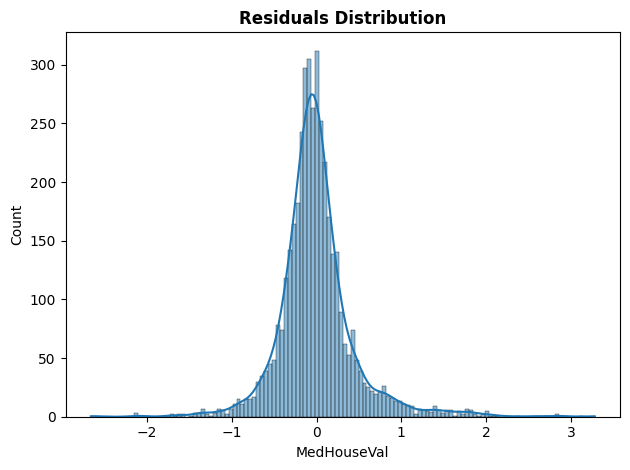

In [43]:
residuals = y_test - y_pred_xgb_fe_tuned
plt.figure()
sns.histplot(residuals, kde=True)
plt.title(f"Residuals Distribution", fontweight="bold")
plt.tight_layout()
plt.show()

The distribution of the residuals (differences between actual and predicted values) is centered around zero, which indicates that the model does not show a significant bias.

The shape of the distribution is approximately bell-shaped, suggesting that most prediction errors are relatively small and symmetrically distributed However, there is a slight asymmetry and the presence of long tails, confirming that the model occasionally makes larger errors for extreme values.

Overall, this analysis suggests that the model performs well for most observations, although it still has some difficulty with outliers and higher values.

In [62]:
importances = pd.Series(
    xgb_fe_best_model.feature_importances_,
    index=X_train_fe.columns
).sort_values(ascending=False)

print("Features Importance:\n")
print(importances.round(3))

Features Importance:

IncomePerHousehold        0.592
MedInc                    0.091
Longitude                 0.066
Latitude                  0.061
HouseAge                  0.039
AveOccup                  0.034
AveRooms                  0.031
BedroomsRatio             0.022
AveBedrms                 0.017
RoomsPerHousehold         0.015
Population                0.015
PopulationPerHousehold    0.015
dtype: float32


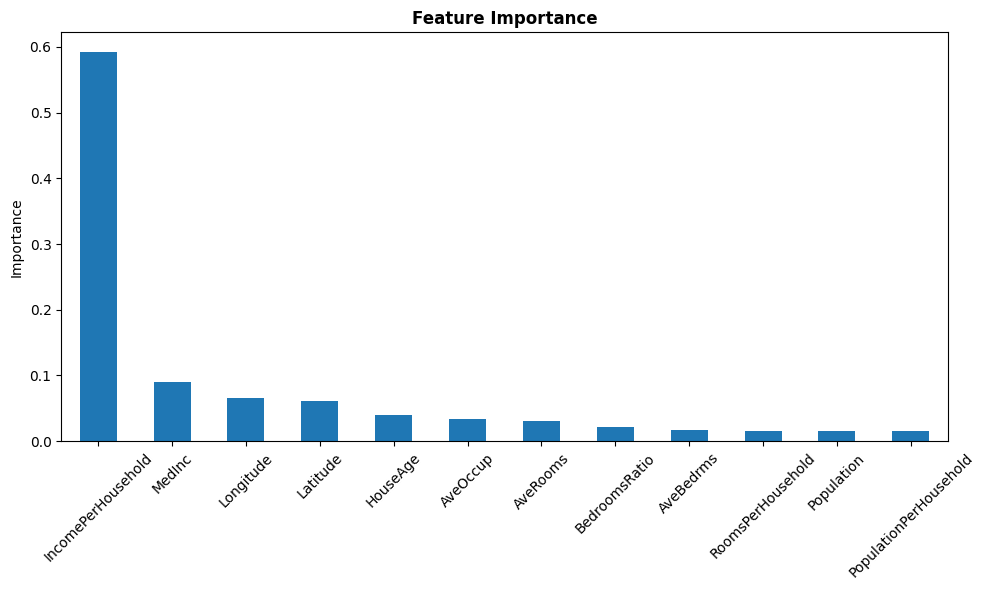

In [45]:
importances.plot(kind="bar", figsize=(10, 6))
plt.title("Feature Importance", fontweight="bold")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The feature importance analysis shows that *IncomePerHousehold* is by far the most influential variable in the prediction. This suggests that the combination of median income and household size is a very strong indicator of house value, and that its introduction during the feature engineering phase was effective. However, such a strong reliance on a single feature should be further investigated.

Other important but secondary features include the geographical coordinates (*Latitude* and *Longitude*), confirming the central role of location, and *MedInc*, which had already shown a strong correlation with the target during the EDA. However, the introduction of *IncomePerHousehold* (which is derived from *MedInc*) seems to have absorbed much of the information contained in this variable, leading the model to rely more heavily on it.

To evaluate the contribution of the most important feature (*IncomePerHousehold*) and the strong reliance of the model on it, the same model was retrained after removing this variable. The goal is to assess whether this feature contains redundant information already present in the dataset, allowing the model to rely on other features in its absence, or whether it is truly essential for achieving good performance.

In [46]:
X_train_fe_drop = X_train_fe.drop(columns=["IncomePerHousehold"])
X_test_fe_drop = X_test_fe.drop(columns=["IncomePerHousehold"])

In [47]:
xgb_fe_drop = XGBRegressor(**random_search.best_params_, random_state=42)

xgb_fe_drop.fit(X_train_fe_drop, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [48]:
y_pred_xbg_fe_drop = xgb_fe_drop.predict(X_test_fe_drop)

In [59]:
rmse = float(np.sqrt(mean_squared_error(y_test, y_pred_xbg_fe_drop)))
mae = float(mean_absolute_error(y_test, y_pred_xbg_fe_drop))
r2 = float(r2_score(y_test, y_pred_xbg_fe_drop))

print("XGBoost with dropped column:\n")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R2: {r2:.3f}")

XGBoost with dropped column:

RMSE: 0.456
MAE: 0.301
R2: 0.842


In [63]:
importances_drop = pd.Series(
    xgb_fe_drop.feature_importances_,
    index=X_train_fe_drop.columns
).sort_values(ascending=False)

print("Features Importance (dropped dataset):\n")
print(importances_drop.round(3))

Features Importance (dropped dataset):

MedInc                    0.353
RoomsPerHousehold         0.138
Latitude                  0.103
Longitude                 0.103
BedroomsRatio             0.094
AveOccup                  0.087
HouseAge                  0.047
AveRooms                  0.032
AveBedrms                 0.016
PopulationPerHousehold    0.014
Population                0.013
dtype: float32


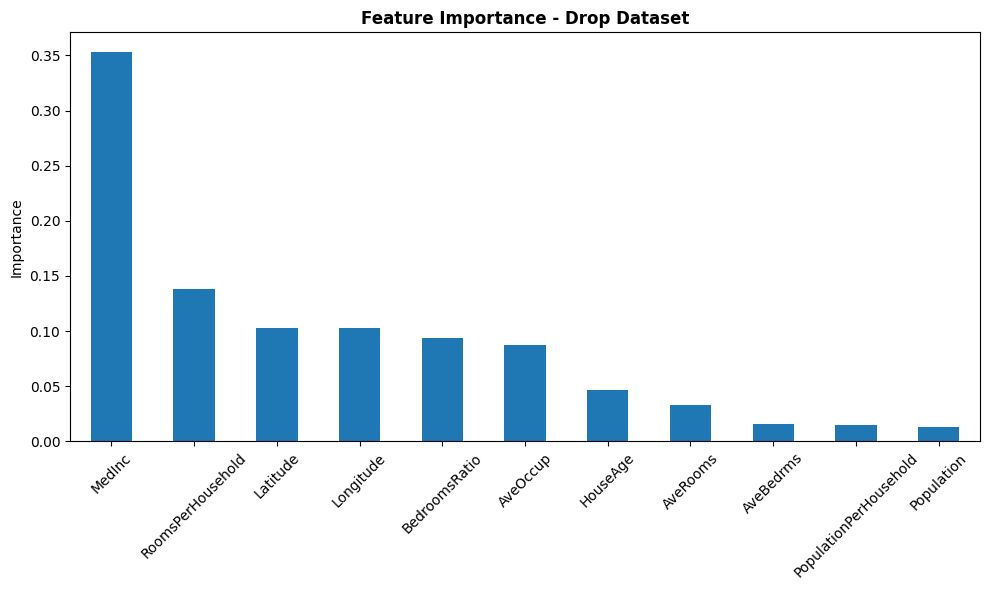

In [64]:
importances_drop.plot(kind="bar", figsize=(10, 6))
plt.title("Feature Importance - Drop Dataset", fontweight="bold")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

To evaluate the role of the dominant feature, a model was trained after removing the IncomePerHousehold variable. The results on the feature-engineered dataset, without IncomePerHousehold, show that performance remains largely unchanged, suggesting that this feature, although highly informative, is partially redundant with respect to other variables.

In particular, MedInc emerges as the main alternative (as expected after observing its strong correlation with the target variable), together with other engineered features and geographical information. This highlights the model’s ability to rely on different combinations of features to achieve similar performance.

Overall, IncomePerHousehold remains a highly influential feature, but its removal does not lead to a significant drop in performance. This suggests that it captures information already present in other variables, indicating a certain degree of redundancy. However, its inclusion is not problematic, as it helps simplify the representation of the problem for the model.

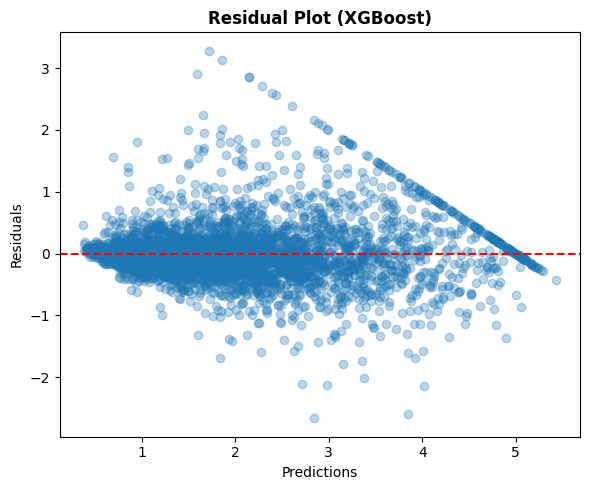

In [65]:
residuals = y_test - y_pred_xgb_fe_tuned

plt.figure(figsize=(6, 5))
plt.scatter(y_pred_xgb_fe_tuned, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predictions")
plt.ylabel("Residuals")
plt.title("Residual Plot (XGBoost)", fontweight="bold")
plt.tight_layout()
plt.show()

The residual plot shows that the errors are centered around zero, indicating the absence of systematic bias in the model. However, an increase in the variance of the residuals can be observed for higher predicted values, suggesting the presence of heteroscedasticity.

Moreover, a linear pattern is visible in the residuals, which is likely due to the usual upper limit of the target variable in the dataset. This limitation introduces a saturation effect in the predictions.

In [66]:
res_lr = y_test - y_pred_linearregression
res_lr_fe = y_test - y_pred_linearregression_fe

res_rf = y_test - y_pred_random_forest
res_rf_fe = y_test - y_pred_random_forest_fe

res_xgb = y_test - y_pred_xgb
res_xgb_fe = y_test - y_pred_xgb_fe_tuned

/tmp/ipykernel_2080/3971492622.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


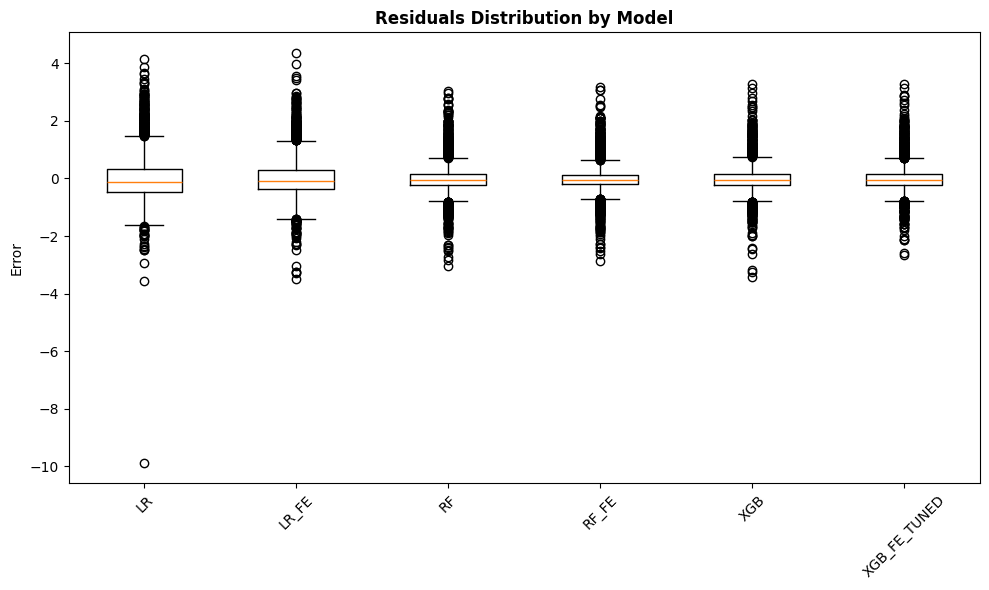

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.boxplot([
    res_lr,
    res_lr_fe,
    res_rf,
    res_rf_fe,
    res_xgb,
    res_xgb_fe
], labels=[
    "LR",
    "LR_FE",
    "RF",
    "RF_FE",
    "XGB",
    "XGB_FE_TUNED"
])

plt.title("Residuals Distribution by Model", fontweight="bold")
plt.ylabel("Error")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The residuals boxplot shows that all models produce errors centered around zero, indicating the absence of bias. However, more complex models, particularly XGBoost, exhibit a more compact error distribution, suggesting greater stability.